<a href="https://colab.research.google.com/github/siwell24/buffer_10km_peta_aceh_diatas_rata_rata/blob/main/PROYEK_MINI_Analisis_Buffer_%26_Peta_Tematik_Kabupaten_Strategis_di_Aceh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

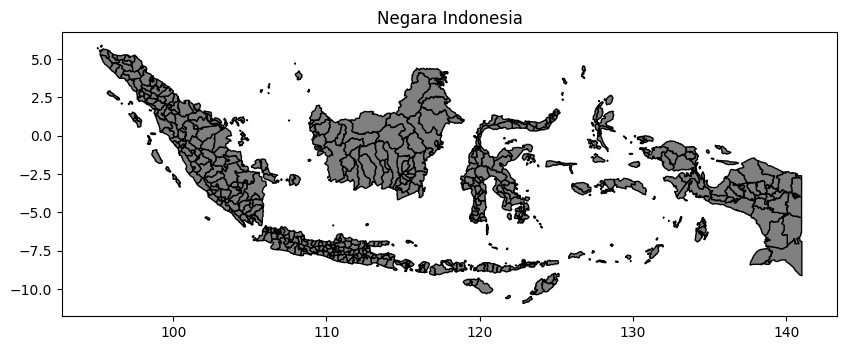

----------------------------------------------------------------------------------------


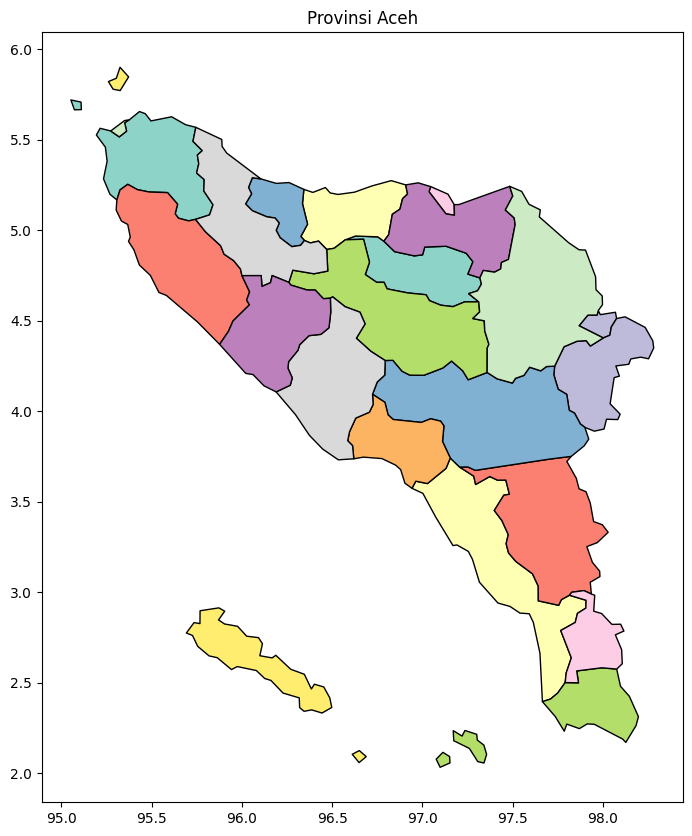

----------------------------------------------------------------------------------------


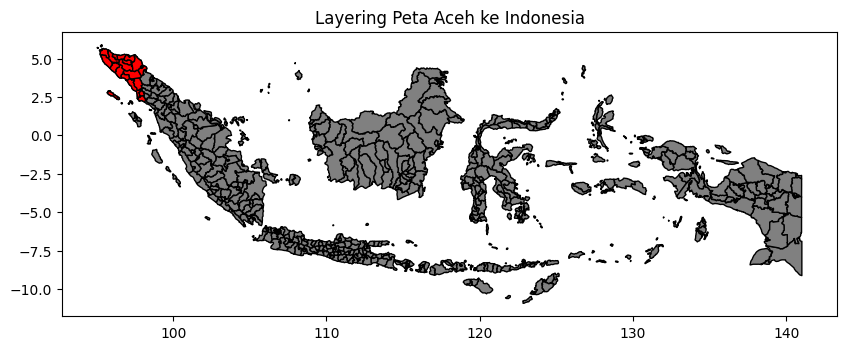

----------------------------------------------------------------------------------------
Peta Aceh UTM berhasil disimpan dalam format PNG di Google Drive!


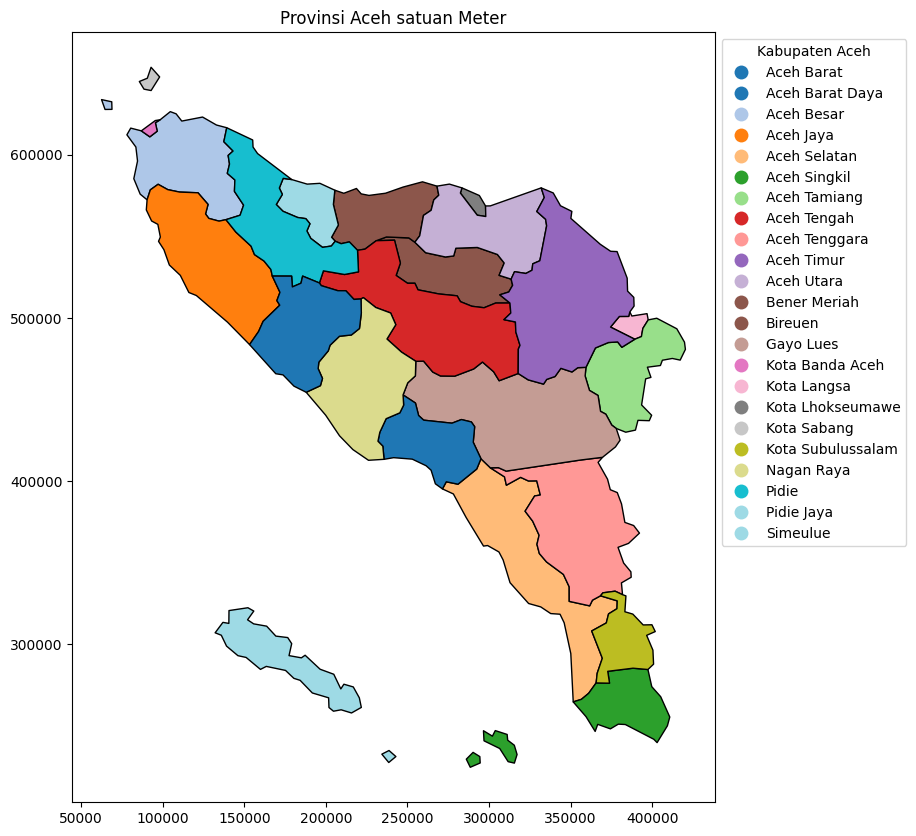

----------------------------------------------------------------------------------------
--- [Tahap 2] Menghitung Luas & Membuat Filter ---
Rata-rata luas kabupaten di Aceh: 2461.26 km²
----------------------------------------------------------------------------------------
Jumlah kabupaten kategori besar (>jumlah rata-rata): 11
--- [Tahap 3] Membuat Zona Buffer 10 km ---

Hasil perhitungan geometry:
                WADMKK     luas_km2
3         Bener Meriah  1905.174924
22          Aceh Besar  2830.461778
32        Aceh Selatan  4172.228591
81             Bireuen  1808.874117
99         Kota Langsa   224.165828
123       Aceh Tamiang  2179.760501
150      Aceh Tenggara  4146.685608
185          Aceh Jaya  3894.211116
199          Gayo Lues  5539.351027
200         Pidie Jaya   950.850294
240    Aceh Barat Daya  1894.586532
247       Aceh Singkil  1815.859291
270        Aceh Tengah  4470.995279
284  Kota Subulussalam  1196.006945
302   Kota Lhokseumawe   133.951457
343         Nagan Ra

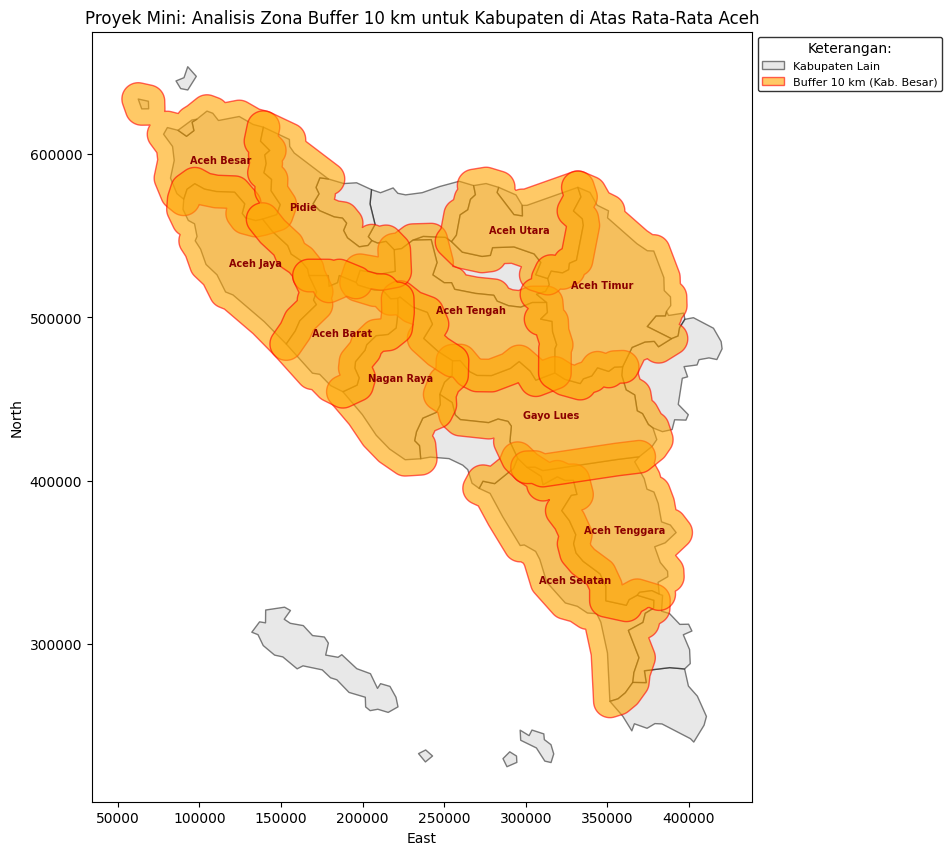

File berhasil diekspor secara permanen ke Google Drive!


In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt

#Memasukkan data provinsi aceh
nama_file = "/content/drive/MyDrive/Learning Phyton/Provinsi Indonesia/38 Provinsi Indonesia - Kabupaten.json"
indonesia = gpd.read_file(nama_file)
provinsi_aceh = indonesia[indonesia["WADMPR"] == "Aceh"]
fig,ax = plt.subplots(figsize=(10,10))
indonesia.plot(
    color="grey",
    edgecolor="black",
    ax=ax) #visual peta indonesia
plt.title("Negara Indonesia")
plt.show()
print ("----------------------------------------------------------------------------------------")

fig,ax = plt.subplots(figsize=(10,10))
provinsi_aceh.plot(
    cmap="Set3",
    edgecolor="black",
    ax=ax) #visual peta aceh
plt.title("Provinsi Aceh")
plt.show()
print ("----------------------------------------------------------------------------------------")

#layering peta aceh ke peta indonesia
fig,ax = plt.subplots(figsize=(10,10))
indonesia.plot(
    color="grey",
    edgecolor="black",
    ax=ax)

provinsi_aceh.plot(
    color="red",
    edgecolor="black",
    ax=ax) #visual peta aceh
plt.title("Layering Peta Aceh ke Indonesia")
plt.show()
print ("----------------------------------------------------------------------------------------")

#menyatukan crs ke dalam satuan meter
aceh_utm = provinsi_aceh.estimate_utm_crs()
provinsi_aceh_utm = provinsi_aceh.to_crs(aceh_utm)
fig,ax = plt.subplots(figsize=(10,10))
provinsi_aceh_utm.plot(
    column = "WADMKK",
    cmap="tab20",
    edgecolor="black",
    legend=True,
    legend_kwds={
        "bbox_to_anchor": (1, 1),
        "title": "Kabupaten Aceh",
        "loc": "upper left"},
    ax=ax) #visual peta aceh dalam satuan meter
plt.title("Provinsi Aceh satuan Meter")
#save to drive png
lokasi_gambar_utm = ("/content/drive/MyDrive/Learning Phyton/Provinsi Indonesia/peta_aceh_utm.png")
fig.savefig(lokasi_gambar_utm, dpi=300, bbox_inches="tight")
print("Peta Aceh UTM berhasil disimpan dalam format PNG di Google Drive!")
plt.show()
print ("----------------------------------------------------------------------------------------")

#MENGHITUNG KALKULASI SPASIAL & FILTERING ATRIBUT
print("--- [Tahap 2] Menghitung Luas & Membuat Filter ---")
provinsi_aceh_utm["luas_km2"] = provinsi_aceh_utm.geometry.area / 1_000_000
rata_luas = provinsi_aceh_utm["luas_km2"].mean()
print(f"Rata-rata luas kabupaten di Aceh: {rata_luas:.2f} km²")
print ("----------------------------------------------------------------------------------------")

#filter kabupaten yang diatas rata-rata luas saja
kabupaten_besar = provinsi_aceh_utm[
    provinsi_aceh_utm["luas_km2"] > rata_luas
].copy()
print(f"Jumlah kabupaten kategori besar (>jumlah rata-rata): {len(kabupaten_besar)}")

#BUFFERING
print("--- [Tahap 3] Membuat Zona Buffer 10 km ---")
#buffer 10km
kabupaten_besar["geometry"] = kabupaten_besar.geometry.buffer(10000)
print("\nHasil perhitungan geometry:")
print(provinsi_aceh_utm[["WADMKK", "luas_km2"]])

#VISUALISASI AKHIR
import matplotlib.patches as mpatches
print("--- [Tahap 4] Membuat Peta Multi-Layer & Labeling ---")
fig, ax = plt.subplots(figsize=(10, 10))

# 1. Layer Dasar
provinsi_aceh_utm.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    alpha=0.5,
    label="Kabupaten Lain"
)

# 2. Layer Utama: Zona Buffer Kabupaten Besar
kabupaten_besar.plot(
    ax=ax,
    color="orange",
    edgecolor="red",
    alpha=0.6,
    label="Buffer 10 km (Kab. Besar)",
)

# 3. Layer Pelengkap: Labeling
for idx, row in kabupaten_besar.iterrows():
  titik_tengah = row.geometry.representative_point()
  ax.text(
      titik_tengah.x,
      titik_tengah.y,
      row["WADMKK"],
      fontsize=7,
      ha="center",
      va="center",
      weight="bold",
      color="darkred",
  )

plt.title(
    "Proyek Mini: Analisis Zona Buffer 10 km untuk Kabupaten di Atas Rata-Rata"
    " Aceh"
)
patch_lain = mpatches.Patch(
    color="lightgray", ec="black", alpha=0.5, label="Kabupaten Lain"
)
patch_buffer = mpatches.Patch(
    color="orange", ec="red", alpha=0.6, label="Buffer 10 km (Kab. Besar)"
)
plt.legend(
    handles=[patch_lain, patch_buffer],
    title="Keterangan:",
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    bbox_to_anchor=(1, 1),
    loc="upper left")
plt.xlabel("East")
plt.ylabel("North")

#export hsil to drive PNG
lokasi_gambar = ("/content/drive/MyDrive/Learning Phyton/Provinsi Indonesia/peta_buffer_aceh.png")
fig.savefig(
    lokasi_gambar,
    dpi=300,
    bbox_inches="tight"
    )
print("Gambar peta berhasil disimpan dalam format PNG di Google Drive!")
plt.show()

#TAHAP 5: EKSPOR HASIL AKHIR
lokasi_simpan = "/content/drive/MyDrive/Learning Phyton/Provinsi Indonesia/Proyek_mini_buffer_Aceh.geojson"
kabupaten_besar.to_file(lokasi_simpan, driver="GeoJSON")
print("File berhasil diekspor secara permanen ke Google Drive!") #to geojson